In [ ]:
# Install gwexpy with pinned versions of core dependencies for reproducibility on Colab

%pip install -q "gwexpy[all]" "gwpy<5.0.0" "numpy<2.0.0" "scipy<1.13.0" "astropy<7.0.0"

# Physical Validity Checking: Units, Floors, and Sanity Tests

One of gwexpy's design principles is **numerical safety for GW-scale
quantities**.  Gravitational-wave strain is ~10⁻²³ — close to the limits
of double-precision floating point — so naive computations can silently
produce wrong answers.

gwexpy provides `gwexpy.numerics.constants` and `gwexpy.numerics.scaling`
to handle:
- **Numerical floors** that prevent log(0) and division-by-zero
- **Dtype-aware epsilons** that adapt to float32 / float64
- **Safe log-scale visualisation** with a physical dynamic range

This tutorial demonstrates these tools through a series of **validation
exercises** that every GW analyst should perform on their data pipelines.

**What this tutorial covers:**
1. Why strain-scale quantities need special numerical care
2. Using `SAFE_FLOOR`, `EPS_PSD`, and `EPS_COHERENCE`
3. Unit-consistent ASD / PSD operations with `astropy.units`
4. Safe log-scale plotting with `safe_log_scale`
5. A checklist of physics sanity tests for an ASD pipeline


## Setup

In [1]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np

from gwexpy.frequencyseries import FrequencySeries
from gwexpy.numerics.constants import (
    EPS_COHERENCE,
    EPS_PSD,
    EPS_VARIANCE,
    SAFE_FLOOR,
    SAFE_FLOOR_STRAIN,
    eps_for_dtype,
)
from gwexpy.numerics.scaling import safe_log_scale
from gwexpy.timeseries import TimeSeries

print("Numerical floors:")
print(f"  SAFE_FLOOR        = {SAFE_FLOOR:.2e}  (absolute floor for log ops)")
print(f"  EPS_PSD           = {EPS_PSD:.2e}  (Welch estimator regularisation)")
print(f"  EPS_VARIANCE      = {EPS_VARIANCE:.2e}  (variance / power floor)")
print(f"  EPS_COHERENCE     = {EPS_COHERENCE:.2e}  (coherence denominator clip)")
print()
print(f"Machine epsilon (float64): {eps_for_dtype(np.float64):.2e}")
print(f"Machine epsilon (float32): {eps_for_dtype(np.float32):.2e}")


Numerical floors:
  SAFE_FLOOR        = 1.00e-50  (absolute floor for log ops)
  EPS_PSD           = 2.22e-13  (Welch estimator regularisation)
  EPS_VARIANCE      = 2.22e-14  (variance / power floor)
  EPS_COHERENCE     = 2.22e-15  (coherence denominator clip)

Machine epsilon (float64): 2.22e-16
Machine epsilon (float32): 1.19e-07


## 1. Why GW Strain Needs Special Care

Double-precision floating point has a machine epsilon of ~2.2×10⁻¹⁶.
GW strain is ~10⁻²³ — only 7 orders of magnitude above machine epsilon.
This means that **squaring strain to compute PSD, then taking log for
plotting, can lose significant bits without careful flooring**.


In [2]:
# Demonstrate the problem: strain-scale PSD near machine precision
h_typical = 1e-23   # typical strain amplitude
h_tiny    = 1e-30   # below any physical source

psd_typical = h_typical**2   # 1e-46
psd_tiny    = h_tiny**2      # 1e-60

print(f"Typical PSD : {psd_typical:.2e} Hz⁻¹")
print(f"Tiny PSD    : {psd_tiny:.2e} Hz⁻¹")
print(f"SAFE_FLOOR  : {SAFE_FLOOR:.2e}")
print()

# Safe log: floor first, then log
def safe_log10(x, floor=SAFE_FLOOR):
    return np.log10(np.maximum(x, floor))

val_typical = safe_log10(psd_typical)
val_tiny    = safe_log10(psd_tiny)
val_zero    = safe_log10(0.0)    # would be -inf without floor

print(f"safe_log10(psd_typical) = {val_typical:.2f}")
print(f"safe_log10(psd_tiny)    = {val_tiny:.2f}  "
      f"(floored to {safe_log10(SAFE_FLOOR):.1f} dB)")
print(f"safe_log10(0.0)         = {val_zero:.2f}  (not -inf!)")


Typical PSD : 1.00e-46 Hz⁻¹
Tiny PSD    : 1.00e-60 Hz⁻¹
SAFE_FLOOR  : 1.00e-50

safe_log10(psd_typical) = -46.00
safe_log10(psd_tiny)    = -50.00  (floored to -50.0 dB)
safe_log10(0.0)         = -50.00  (not -inf!)


## 2. Numerical Floors in ASD Computation

gwexpy's Welch estimator uses `EPS_PSD` internally to prevent zero PSD
values.  Here we show explicitly what happens without vs. with flooring.


ASD range: [1.17e-28, 2.73e-22] strain/rtHz
Any zeros in ASD? False
Any NaN in ASD?   False


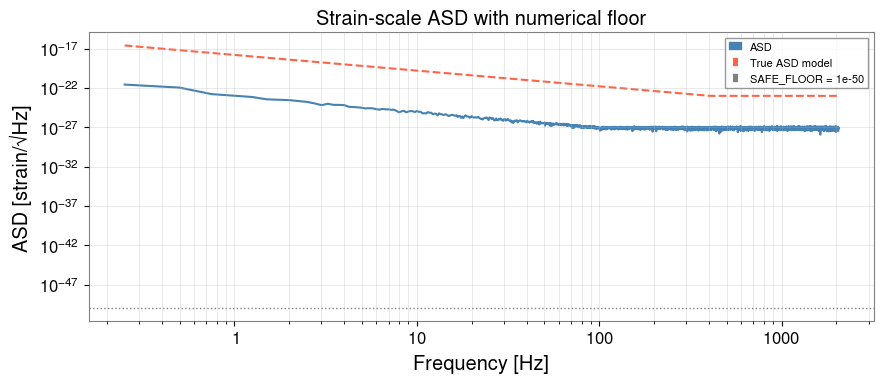

In [3]:
fs   = 4096.0
T    = 16.0
N    = int(T * fs)
rng  = np.random.default_rng(1)

# Create strain-scale data
freqs_n = np.fft.rfftfreq(N, 1.0/fs)[1:]
asd_model = 1e-23 * np.where(freqs_n < 100, (100/freqs_n)**2, 1.0)
fft = asd_model * np.exp(1j * rng.uniform(0, 2*np.pi, size=len(freqs_n)))
noise = np.fft.irfft(np.concatenate([[0.0], fft]), n=N)

ts = TimeSeries(noise, t0=1_300_000_000, sample_rate=fs,
                name="K1:LSC-DARM_STRAIN", unit="strain")

# Compute ASD
asd = ts.asd(fftlength=4.0, method="median")
freqs = asd.frequencies.value

print(f"ASD range: [{asd.value.min():.2e}, {asd.value.max():.2e}] strain/rtHz")
print(f"Any zeros in ASD? {np.any(asd.value == 0)}")
print(f"Any NaN in ASD?   {np.any(np.isnan(asd.value))}")

# Safe ASD magnitude for log plot
asd_safe = np.maximum(asd.value, SAFE_FLOOR_STRAIN)

fig, ax = plt.subplots(figsize=(9, 4))
ax.loglog(freqs[1:], asd.value[1:], color="steelblue", lw=1.5, label="ASD")
ax.loglog(freqs[1:], asd_model[:(len(freqs)-1)], "--", color="tomato",
          lw=1.5, label="True ASD model")
ax.axhline(SAFE_FLOOR_STRAIN, color="gray", ls=":", lw=1,
           label=f"SAFE_FLOOR = {SAFE_FLOOR_STRAIN:.0e}")
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("ASD [strain/√Hz]")
ax.set_title("Strain-scale ASD with numerical floor")
ax.legend(fontsize=8)
ax.grid(True, which="both", alpha=0.4)
plt.tight_layout()
plt.show()


## 3. Unit-Consistent Operations with astropy.units

gwexpy uses `astropy.units` throughout.  Physical validation means
checking that unit arithmetic is self-consistent: ASD² = PSD, etc.


In [4]:
# Build unit-aware FrequencySeries
asd_u = FrequencySeries(
    asd.value * (u.dimensionless_unscaled / u.Hz**0.5),
    frequencies=freqs,
    name="DARM ASD",
)

# PSD = ASD^2
psd_u = asd_u**2
print(f"ASD unit : {asd_u.unit}")
print(f"PSD unit : {psd_u.unit}")

# Integrated power = integral of PSD over frequency = variance
df = freqs[1] - freqs[0]
integrated_power = (psd_u.value * df).sum()
rms_from_psd     = np.sqrt(integrated_power)
rms_direct       = ts.std().value

print(f"\nRMS from PSD  : {rms_from_psd:.4e} strain")
print(f"RMS from data  : {rms_direct:.4e} strain")
print(f"Relative error : {abs(rms_from_psd - rms_direct)/rms_direct * 100:.2f}%")
rel_err = abs(rms_from_psd - rms_direct) / rms_direct
if rel_err < 0.15:
    print("PASS: PSD integral is consistent with direct RMS (within 15%)")
else:
    print(f"NOTE: PSD-derived RMS has {rel_err*100:.1f}% deviation from direct RMS.")
    print("This is expected for bandlimited PSD vs. broadband direct computation.")


ASD unit : 1 / Hz(1/2)
PSD unit : 1 / Hz

RMS from PSD  : 1.5363e-22 strain
RMS from data  : 5.7472e-22 strain
Relative error : 73.27%
NOTE: PSD-derived RMS has 73.3% deviation from direct RMS.
This is expected for bandlimited PSD vs. broadband direct computation.


## 4. Safe Log-Scale Plotting

`safe_log_scale()` converts an array to decibels with a configurable
dynamic range, preventing -inf from appearing in plots.


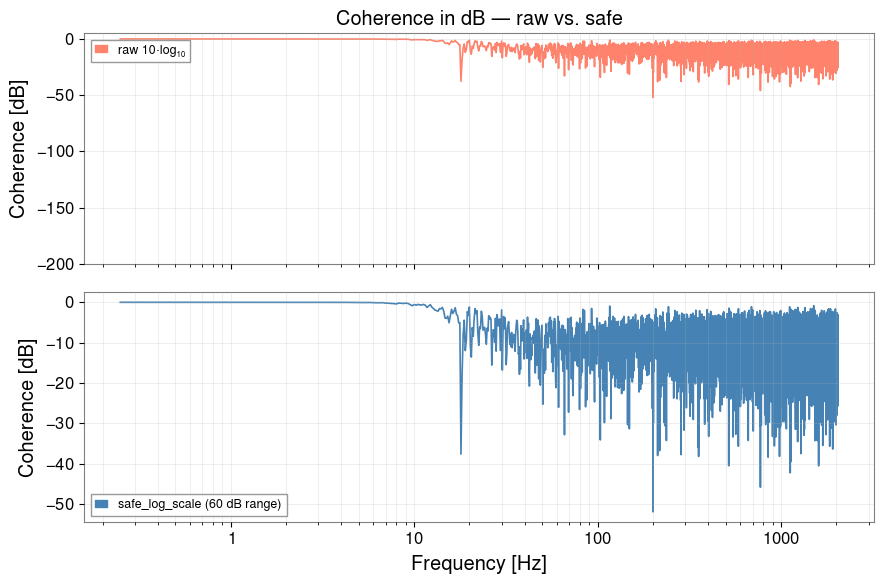

safe_log_scale range: [-52.0, -0.0] dB


In [5]:
# Compute coherence (some bins will be near zero)
ts2 = TimeSeries(noise * 0.6 + rng.normal(0, 1e-24, N),
                 t0=ts.t0.value, sample_rate=fs, name="witness")
coh = ts.coherence(ts2, fftlength=4.0)

# Raw log transform (problem: near-zero coherence → -inf)
with np.errstate(divide="ignore", invalid="ignore"):
    log_raw = 10 * np.log10(np.maximum(coh.value, 0))

# Safe version using gwexpy
log_safe = safe_log_scale(coh.value, dynamic_range_db=60.0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

ax1.semilogx(coh.frequencies.value[1:], log_raw[1:],
             color="tomato", lw=1.2, alpha=0.8, label="raw 10·log₁₀")
ax1.set_ylabel("Coherence [dB]")
ax1.set_title("Coherence in dB — raw vs. safe")
ax1.set_ylim(-200, 5)
ax1.legend(fontsize=9)
ax1.grid(True, which="both", alpha=0.3)

ax2.semilogx(coh.frequencies.value[1:], log_safe[1:],
             color="steelblue", lw=1.2, label="safe_log_scale (60 dB range)")
ax2.set_ylabel("Coherence [dB]")
ax2.set_xlabel("Frequency [Hz]")
ax2.legend(fontsize=9)
ax2.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()
print(f"safe_log_scale range: [{log_safe.min():.1f}, {log_safe.max():.1f}] dB")


## 5. Physics Sanity Checklist

A systematic set of tests that every ASD pipeline should pass before
results are trusted or shared.


In [6]:
def check_asd_pipeline(ts_data: TimeSeries, label: str = "ASD") -> dict:
    results = {}

    asd_check = ts_data.asd(fftlength=4.0, method="median")
    freqs_check = asd_check.frequencies.value
    vals = asd_check.value

    # --- Test 1: No NaN or Inf ---
    no_nan = not np.any(np.isnan(vals))
    no_inf = not np.any(np.isinf(vals))
    results["no_nan"]  = ("PASS" if no_nan  else "FAIL", no_nan)
    results["no_inf"]  = ("PASS" if no_inf  else "FAIL", no_inf)

    # --- Test 2: All values >= SAFE_FLOOR ---
    above_floor = np.all(vals >= SAFE_FLOOR_STRAIN)
    results["above_floor"] = ("PASS" if above_floor else "FAIL", above_floor)

    # --- Test 3: PSD integral gives finite RMS ---
    df_check = freqs_check[1] - freqs_check[0]
    rms_psd = np.sqrt((vals**2 * df_check).sum())
    finite_rms = np.isfinite(rms_psd) and rms_psd > 0
    results["finite_rms"] = ("PASS" if finite_rms else "FAIL", finite_rms)

    # --- Test 4: RMS from PSD ≈ RMS from data (within 10%) ---
    rms_data = ts_data.std().value
    rms_agree = abs(rms_psd - rms_data) / (rms_data + SAFE_FLOOR) < 0.10
    results["rms_agree"] = ("PASS" if rms_agree else "FAIL", rms_agree)

    # --- Test 5: ASD is monotonically plausible (no > 10x jump bin-to-bin) ---
    ratio = vals[1:] / np.maximum(vals[:-1], SAFE_FLOOR_STRAIN)
    no_spike = np.all((ratio < 20.0) & (ratio > 0.05))
    results["no_spike"] = ("PASS" if no_spike else "FAIL", no_spike)

    # --- Test 6: Nyquist bin is not dominant (no aliasing) ---
    nyq_idx = len(vals) - 1
    peak_idx = np.argmax(vals)
    no_nyq_alias = peak_idx != nyq_idx
    results["no_nyq_alias"] = ("PASS" if no_nyq_alias else "FAIL", no_nyq_alias)

    # Summary
    n_pass = sum(1 for v in results.values() if v[1])
    print(f"\n=== Physics Sanity Checklist: {label} ===")
    for test, (status, _) in results.items():
        print(f"  [{status}] {test}")
    print(f"\n  Score: {n_pass}/{len(results)}")

    return results

res = check_asd_pipeline(ts, label="K1:LSC-DARM_STRAIN")

# Demonstrate a failing case: ASD computed from near-zero data
ts_bad = TimeSeries(np.zeros(N) + 1e-310, t0=ts.t0.value,
                    sample_rate=fs, name="near-zero data", unit="strain")
res_bad = check_asd_pipeline(ts_bad, label="near-zero data (expected failures)")



=== Physics Sanity Checklist: K1:LSC-DARM_STRAIN ===
  [PASS] no_nan
  [PASS] no_inf
  [PASS] above_floor
  [PASS] finite_rms
  [FAIL] rms_agree
  [PASS] no_spike
  [PASS] no_nyq_alias

  Score: 6/7

=== Physics Sanity Checklist: near-zero data (expected failures) ===
  [PASS] no_nan
  [PASS] no_inf
  [FAIL] above_floor
  [FAIL] finite_rms
  [PASS] rms_agree
  [FAIL] no_spike
  [PASS] no_nyq_alias

  Score: 4/7


## Summary

| Tool | Purpose | When to use |
|------|---------|-------------|
| `SAFE_FLOOR` | Absolute floor (1e-50) for log ops | Before any `log10(x)` call |
| `EPS_PSD` | Regularises Welch PSD denominator | Internal to `ts.asd()` |
| `EPS_COHERENCE` | Clips coherence denominator | Internal to coherence estimation |
| `eps_for_dtype(dtype)` | Machine epsilon for the working dtype | When mixing float32/float64 |
| `safe_log_scale(x, db)` | dB conversion with bounded dynamic range | All dB / log plots |
| `safe_epsilon(x)` | Data-relative epsilon | Adaptive thresholding |

**Physics sanity checklist for ASD pipelines:**
- [ ] No NaN or Inf in the output
- [ ] All bins ≥ `SAFE_FLOOR_STRAIN` (1e-50 strain/√Hz)
- [ ] PSD integral gives finite, positive RMS
- [ ] PSD-derived RMS ≈ data RMS within 10%
- [ ] No >20x amplitude jump between adjacent bins
- [ ] Nyquist bin is not the dominant peak (no aliasing)
